# Lab 9 Report: 
## Final Project Codebase

## Project Title: Exploring Topological Data Analysis for Stellar Classification

### Group Members: Madison Ringham and Sean Kawano

In [77]:
# importing necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import gudhi
from gudhi import RipsComplex
from gudhi.representations import PersistenceImage

In [358]:
# useful function for picking the 50 sample points for our persistance image process

def k_means_clustering(data, cluster_size):
    kmeans = KMeans(n_clusters=cluster_size, random_state=42).fit(data)
    centroids = kmeans.cluster_centers_
    rep_id = pairwise_distances_argmin(centroids, data)
    clustering = data[rep_id]
    return clustering

--------------------

## Prepare Data

In [91]:
# importing the data
data = pd.read_csv("star_classification.csv")

# scanning for weird values and dropping that
data = data.replace(-9999,np.NaN) 
data = data.dropna()

# adding a label dictionary to attach each class of object to a number
label_dict = {"GALAXY":0,"QSO":1,"STAR":2}

# scaling and selecting the features we want to use in the model training
scaler = StandardScaler()
feature_list = ["u","g", "redshift"]
data[feature_list] = scaler.fit_transform(data[feature_list])
threshold = 4
data = data[~ (data[feature_list]**2 > threshold**2).any(axis=1)]

# scaling the redshift
data["redshift"] = 1/(1+data["redshift"])

# setting X and y for model training
X = data[feature_list].to_numpy()
y = data["class"].replace(label_dict).to_numpy()

/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_56358/2502706827.py:23: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = data["class"].replace(label_dict).to_numpy()


In [92]:
# splitting into training, testing, and validation sets
train_features, test_features, train_targets, test_targets = train_test_split(
                                                X, 
                                                y, 
                                                test_size=0.1, 
                                                random_state=2)


validation_features, test_features, validation_targets, test_targets = train_test_split(
                                                    test_features, 
                                                    test_targets, 
                                                    test_size=0.5, 
                                                    random_state=2)

### Generate Persistence Imgaes

In [93]:
# setting the resolution of the persistence images to 20x20 pixels
img_res = 20
num_of_classes = len(np.unique(y))
input_dim = len(X[0])

In [94]:
# generating the persistance image
def gen_persistence_image(input, cluster):
    point_cloud = np.vstack((input,cluster))
    rips = RipsComplex(points = point_cloud)
    simplex_tree = rips.create_simplex_tree(max_dimension=2)
    diag = simplex_tree.persistence()
    diag_intervals = np.array([i[1] for i in diag if i[1][1] != np.inf])
    PI = PersistenceImage(resolution=[img_res, img_res]).fit_transform([diag_intervals])
    return PI

# Sorting our features by label
galaxies = train_features[train_targets == 0] #GALAXY
quasars = train_features[train_targets == 1] #QSO
stars = train_features[train_targets == 2 ] #STAR

data_by_cat = [galaxies, quasars, stars]

#Sampling 50 example points from each category
galaxy_sample = k_means_clustering(galaxies, 50)
quasar_sample = k_means_clustering(quasars, 50)
star_sample = k_means_clustering(stars, 50)

clusters = [galaxy_sample,quasar_sample,star_sample]

#Initializing our feature arrays to fill with persistence images
X_train = np.zeros((len(train_features),num_of_classes,img_res*img_res))
X_validation = np.zeros((len(validation_features),num_of_classes,img_res*img_res))
X_test = np.zeros((len(test_features),num_of_classes,img_res*img_res))

for X,y in [(train_features,X_train),(test_features,X_test),(validation_features,X_validation)]:
    for i in range(len(X)):
        for j in range(num_of_classes):
            y[i][j] = gen_persistence_image(X[i],clusters[j])


train_features = np.reshape(X_train, (len(X_train), 3, img_res, img_res))
validation_features = np.reshape(X_validation, (len(X_validation), 3, img_res, img_res))
test_features = np.reshape(X_test, (len(X_test), 3, img_res, img_res))

In [ ]:
# the above cell took 33 min to run!!

tensor(2)


/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_56358/2741420471.py:13: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 1 Axes> than <Figure size 1000x400 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax)


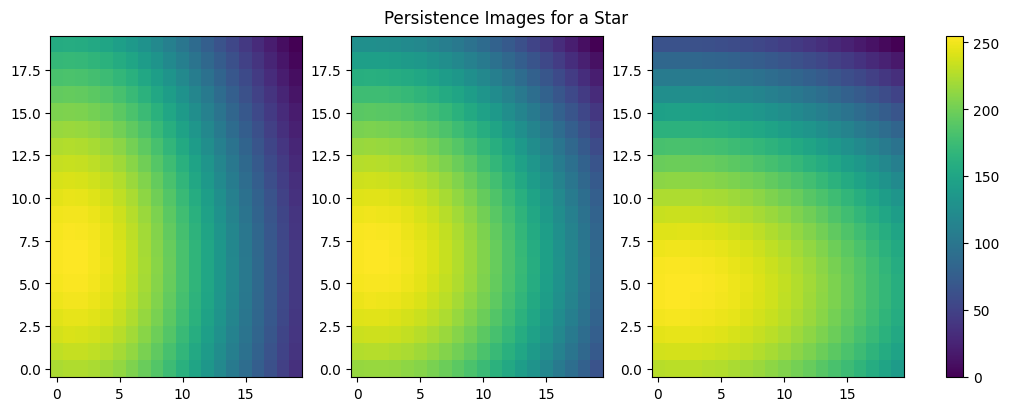

In [366]:
# plotting an example of a star persistance image with 3 channels (galaxy, quasar, star)
# select index i based on the object class we want to visualize

i = 7 # star
fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(10,4),layout='compressed') 
plt.suptitle('Persistence Images for a Star')
im1 = ax[0].imshow(train_features[i][0], origin="lower", cmap="viridis", aspect="auto")

im2 = ax[1].imshow(train_features[i][1], origin="lower", cmap="viridis", aspect="auto")

im3 = ax[2].imshow(train_features[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.colorbar(im, ax=ax) 

print(train_targets[i])
plt.show()

tensor(0)


/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_56358/308467260.py:13: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 1 Axes> than <Figure size 1000x400 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax)


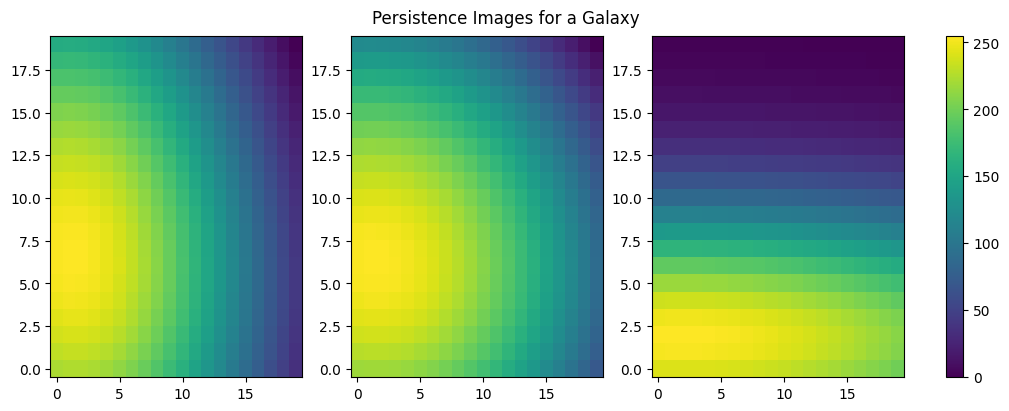

In [368]:
# plotting an example of a galaxy persistance image with 3 channels

i = 12 # galaxy

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(10,4),layout='compressed') 
plt.suptitle('Persistence Images for a Galaxy')
im1 = ax[0].imshow(train_features[i][0], origin="lower", cmap="viridis", aspect="auto")

im2 = ax[1].imshow(train_features[i][1], origin="lower", cmap="viridis", aspect="auto")

im3 = ax[2].imshow(train_features[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.colorbar(im, ax=ax) 

print(train_targets[i])
plt.show();

tensor(1)


/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_56358/250703111.py:14: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 1 Axes> than <Figure size 1000x400 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax)


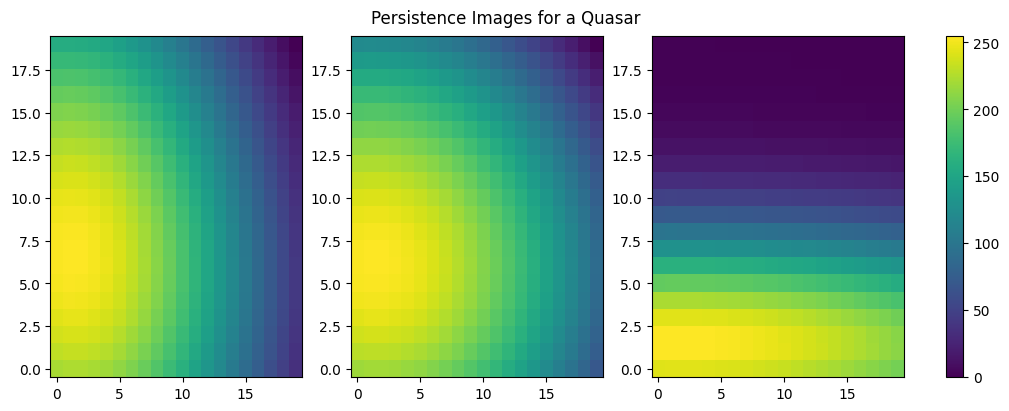

In [370]:
# plotting an example of a quasar persistance image with 3 channels

i = 13 # quasar

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(10,4),layout='compressed') 
plt.suptitle('Persistence Images for a Quasar')

im1 = ax[0].imshow(train_features[i][0], origin="lower", cmap="viridis", aspect="auto")

im2 = ax[1].imshow(train_features[i][1], origin="lower", cmap="viridis", aspect="auto")

im3 = ax[2].imshow(train_features[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.colorbar(im, ax=ax) 

print(train_targets[i])
plt.show()

In [374]:
# making a 3 color image for a star, where the r-g-b channels correspond to galaxy-quasar-star

i = 7 # star

# normalizing data to 0-255
data_norm = (train_features[i] - train_features[i].min()) / (train_features[i].max() - train_features[i].min())
data_255 = (data_norm * 255).astype(np.uint8)

# creating the channels
red_channel = data_255[0]
green_channel = data_255[1]
blue_channel = data_255[2]

# stacking and plotting the 3-color image
rgb_image_star = np.dstack((red_channel,green_channel,blue_channel))

In [375]:
# making a 3 color image for a galaxy, where the r-g-b channels correspond to galaxy-quasar-star

i = 12 # galaxy

# normalizing data to 0-255
data_norm = (train_features[i] - train_features[i].min()) / (train_features[i].max() - train_features[i].min())
data_255 = (data_norm * 255).astype(np.uint8)

# creating the channels
red_channel_g = data_255[0]
green_channel_g = data_255[1]
blue_channel_g = data_255[2]

# stacking and plotting the 3-color image
rgb_image_galaxy = np.dstack((red_channel_g,green_channel_g,blue_channel_g))

In [376]:
# making a 3 color image for a quasar, where the r-g-b channels correspond to galaxy-quasar-star

i = 13 # quasar

# normalizing data to 0-255
data_norm = (train_features[i] - train_features[i].min()) / (train_features[i].max() - train_features[i].min())
data_255 = (data_norm * 255).astype(np.uint8)

# creating the channels
red_channel_q = data_255[0]
green_channel_q = data_255[1]
blue_channel_q = data_255[2]

# stacking and plotting the 3-color image
rgb_image_quasar = np.dstack((red_channel_q,green_channel_q,blue_channel_q))

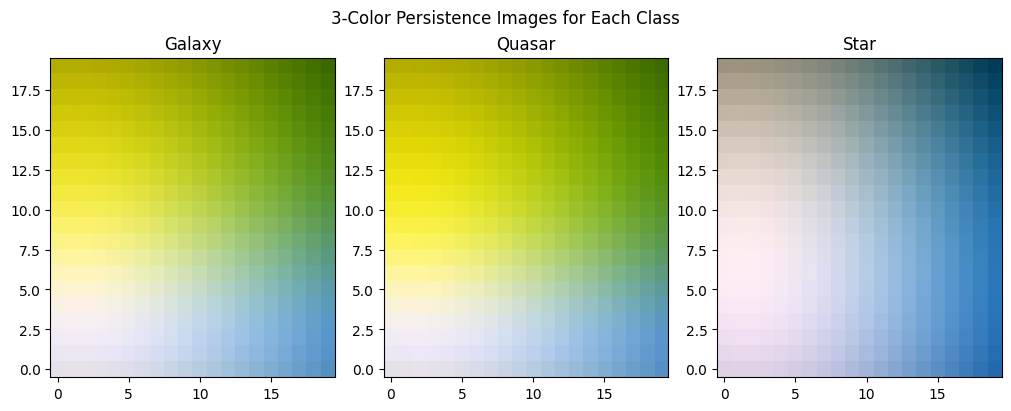

In [377]:
# plotting an example of a quasar persistance image with 3 channels

i = 13 # quasar

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(10,4),layout='compressed') 
plt.suptitle('3-Color Persistence Images for Each Class')

im1 = ax[0].imshow(rgb_image_galaxy, origin="lower", cmap="viridis", aspect="auto")
ax[0].set_title('Galaxy')

im2 = ax[1].imshow(rgb_image_quasar, origin="lower", cmap="viridis", aspect="auto")
ax[1].set_title('Quasar')

im3 = ax[2].imshow(rgb_image_star, origin="lower", cmap="viridis", aspect="auto")
ax[2].set_title('Star')

plt.show();

Since the galaxy and quasar plots look very similar, we decided to create a difference image to see if there was a difference between the two classes.

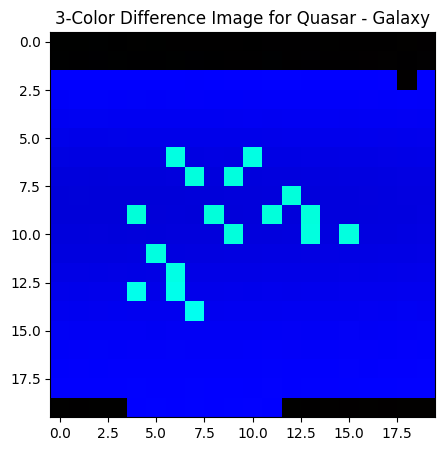

In [381]:
# subtracting the galaxy from quasar plot to see the difference

red = red_channel_q - red_channel_g
green = green_channel_q - green_channel_g
blue =  blue_channel_q - blue_channel_g

plt.figure(figsize=(10, 5))
plt.title('3-Color Difference Image for Quasar - Galaxy')

difference_image = np.dstack((red,green,blue))

plt.imshow(difference_image);

/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_56358/1272259675.py:11: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 1 Axes> than <Figure size 1000x400 with 4 Axes> which fig.colorbar is called on.
  plt.colorbar(im, ax=ax)


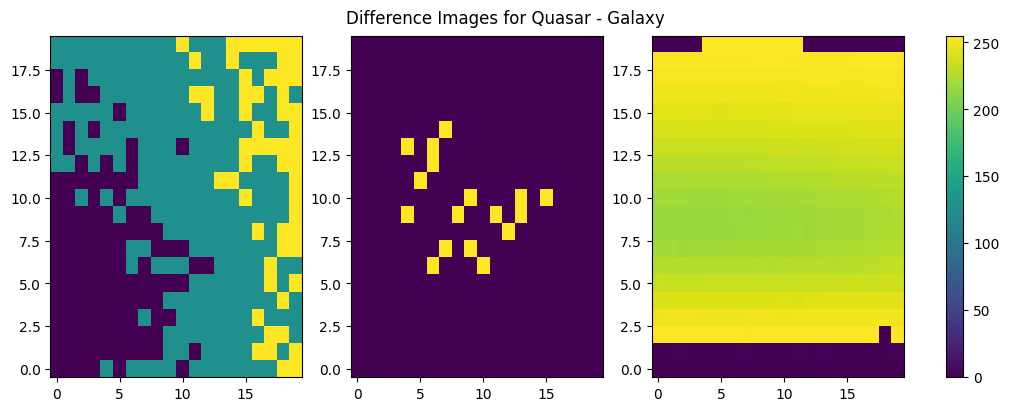

In [383]:
# looking at the quasar-galaxy difference in each channel

fig, ax = plt.subplots(nrows=1, ncols=3,figsize=(10,4),layout='compressed') 
plt.suptitle('Difference Images for Quasar - Galaxy')
im1 = ax[0].imshow(red, origin="lower", cmap="viridis", aspect="auto")

im2 = ax[1].imshow(green, origin="lower", cmap="viridis", aspect="auto")

im3 = ax[2].imshow(blue, origin="lower", cmap="viridis", aspect="auto")

plt.colorbar(im, ax=ax) 

plt.show()

From these difference plots, there is a slight difference in the quasar and galaxy persistance images we selected. We hope that the CNN model can pick up on these slight differences.

# Model 1: TDA and CNN

## Define Model

In [414]:
import torch.nn as nn

class simpleCNN(nn.Module):
    def __init__(self, num_channels, num_of_classes, image_res, hidden_layer_size):

        super(simpleCNN, self).__init__()

        #The convolutional block consists of one convolutional layer
        self.conv_layers = nn.Sequential(
            nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1),
        )

        # The fully connected block, dropout for regularization
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(num_channels * img_res * img_res, hidden_layer_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_layer_size, num_of_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        # using relu activation
        x = torch.nn.functional.relu(self.fc_layers(x))
        return x

## Define Hyperparameters

In [416]:
model = simpleCNN(
    num_channels = 3, 
    num_of_classes = 3, 
    image_res = img_res,
    hidden_layer_size = 40,
    
)

learning_rate = 0.0001
epochs  = 30

# section for adding weights to the model, this reduces accuracy so we decided
# not to use the weights in our final model
class_counts=np.bincount(train_targets)
total_samples=len(train_targets)
weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.FloatTensor(weights)

# loss_func = torch.nn.CrossEntropyLoss(weight=class_weights_tensor) # old loss function with weights

loss_func = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

## Identify Tracked Values

In [417]:
train_loss_list = []
validation_accuracy_list = np.zeros((epochs,))

In [ ]:
# Convert the training, validation, testing dataset (NumPy arrays) into torch tensors
# Split your training features/targets into mini-batches if using mini-batch gradient

train_inputs = torch.from_numpy(train_features).float()
train_targets = torch.from_numpy(train_targets.astype(int))

validation_inputs = torch.from_numpy(validation_features).float()
validation_targets = torch.from_numpy(validation_targets.astype(int))

testing_inputs = torch.from_numpy(test_features).float()
testing_targets = torch.from_numpy(test_targets.astype(int)) 

In [418]:
batchsize = 1000

# Use torch.split() function to split the training inputs/targets into mini-batches
train_batches_features = torch.split(train_inputs, batchsize)
train_batches_targets = torch.split(train_targets, batchsize)

# length of train_batches_features = total number of mini-batches in the training set
batch_split_num = len(train_batches_features)

## Train Model

In [420]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar

for epoch in range(epochs):
    model.train() # Set the model to training mode
    
    for k in range(batch_split_num):
    
        optimizer.zero_grad()
            
        train_batch_outputs = model(train_batches_features[k])

        loss = loss_func(train_batch_outputs, train_batches_targets[k])

        train_loss_list.append(loss.item())

        loss.backward()

        optimizer.step()

    # Compute Validation Accuracy ----------------------------------------------------------------------

    with torch.no_grad():
        model.eval() # Set the model to evaluation mode to turn off dropout layers

        validation_outputs = model(validation_inputs)

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor)
        
        validation_accuracy = np.round(correct.mean().numpy() * 100, 2)
        
        print("Epoch: "+ str(epoch), 
              "Validation Accuracy: " + str(validation_accuracy) + '%', flush=True)
        
        
        

        validation_accuracy_list[epoch] = correct.mean()


Epoch: 0 Validation Accuracy: 89.4%
Epoch: 1 Validation Accuracy: 90.61%
Epoch: 2 Validation Accuracy: 90.83%
Epoch: 3 Validation Accuracy: 89.94%
Epoch: 4 Validation Accuracy: 90.69%
Epoch: 5 Validation Accuracy: 89.74%
Epoch: 6 Validation Accuracy: 89.84%
Epoch: 7 Validation Accuracy: 90.45%
Epoch: 8 Validation Accuracy: 90.35%
Epoch: 9 Validation Accuracy: 90.49%
Epoch: 10 Validation Accuracy: 90.08%
Epoch: 11 Validation Accuracy: 90.08%
Epoch: 12 Validation Accuracy: 90.14%
Epoch: 13 Validation Accuracy: 90.12%
Epoch: 14 Validation Accuracy: 90.83%
Epoch: 15 Validation Accuracy: 90.12%
Epoch: 16 Validation Accuracy: 90.61%
Epoch: 17 Validation Accuracy: 90.39%
Epoch: 18 Validation Accuracy: 91.41%
Epoch: 19 Validation Accuracy: 90.71%
Epoch: 20 Validation Accuracy: 90.59%
Epoch: 21 Validation Accuracy: 92.06%
Epoch: 22 Validation Accuracy: 90.95%
Epoch: 23 Validation Accuracy: 91.55%
Epoch: 24 Validation Accuracy: 90.79%
Epoch: 25 Validation Accuracy: 90.47%
Epoch: 26 Validation Ac

## Visualize & Evaluate Model

Text(0, 0.5, 'validation accuracy')

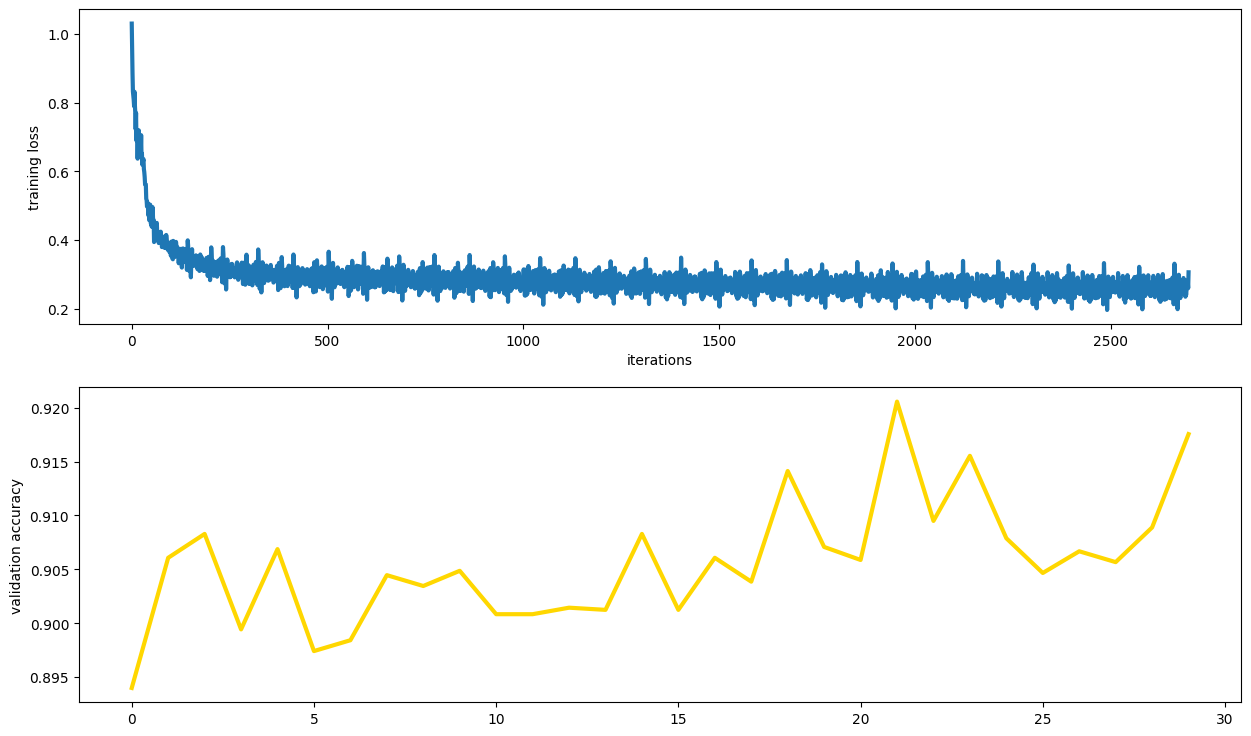

In [421]:
plt.figure(figsize = (15, 9))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("iterations")


plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")

Testing Accuracy: 0.91514176


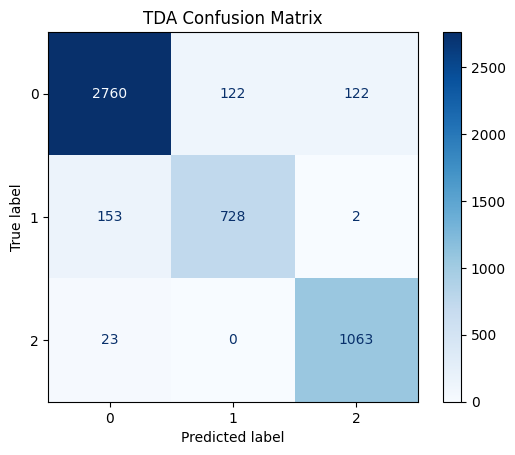

In [422]:
# Compute the testing accuracy 

with torch.no_grad():
    model.eval() # Set the model to evaluation mode to turn off dropout layers
    
    y_pred_test = model(testing_inputs)
     
    correct = (torch.argmax(y_pred_test, dim=1) == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(testing_targets, torch.argmax(y_pred_test, dim=1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("TDA Confusion Matrix")
plt.show()

In [423]:
# galaxy accuracy
galaxy_mask = np.where(testing_targets==0)
galaxies_correct = np.mean((testing_targets[galaxy_mask]==torch.argmax(y_pred_test[galaxy_mask], dim=1)).numpy())

# quasar accuracy
quasar_mask = np.where(testing_targets==1)
quasar_correct = np.mean((testing_targets[quasar_mask]==torch.argmax(y_pred_test[quasar_mask], dim=1)).numpy())

# star accuracy
star_mask = np.where(testing_targets==2)
star_correct = np.mean((testing_targets[star_mask]==torch.argmax(y_pred_test[star_mask], dim=1)).numpy())

print(f'Galaxy accuracy: {(galaxies_correct*100):.2f}%')
print(f'Quasar accuracy: {(quasar_correct*100):.2f}%')
print(f'Star accuracy: {(star_correct*100):.2f}%')

Galaxy accuracy: 91.88%
Quasar accuracy: 82.45%
Star accuracy: 97.88%


In [166]:
# printing out incorrect predictions of stars, galaxies, and quasars

In [174]:
galaxies_incorrect = np.where((testing_targets[galaxy_mask]!=torch.argmax(y_pred_test[galaxy_mask], dim=1)).numpy())
quasar_incorrect = np.where((testing_targets[quasar_mask]!=torch.argmax(y_pred_test[quasar_mask], dim=1)).numpy())
star_incorrect = np.where((testing_targets[star_mask]!=torch.argmax(y_pred_test[star_mask], dim=1)).numpy())

Predicted: Quasar. Actual: Quasar
tensor(1) 1


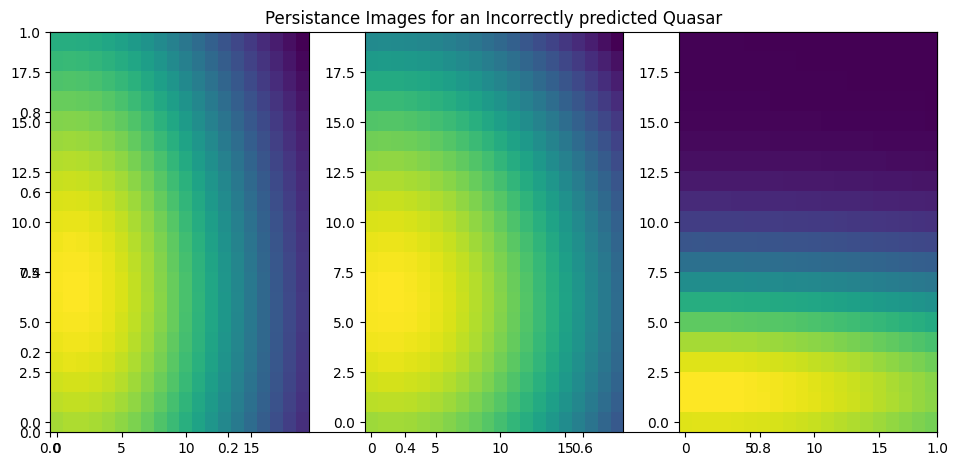

In [424]:
# star
i = star_incorrect[0][1]
plt.figure(figsize=(10, 5))
plt.title('Persistance Images for an Incorrectly predicted Quasar')
plt.subplot(1,3,1)
plt.imshow(testing_inputs[i][0], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,2)
plt.imshow(testing_inputs[i][1], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,3)
plt.imshow(testing_inputs[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.tight_layout()

print(f'Predicted: Quasar. Actual: Quasar')
print(torch.argmax(y_pred_test[i]),test_targets[i])

plt.show()

Predicted: Quasar. Actual: Star
tensor(2) 2


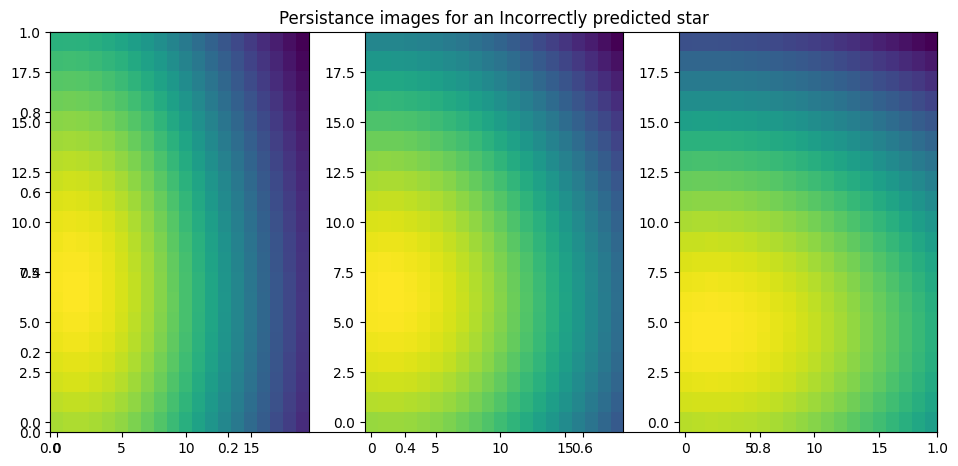

In [425]:
# quasar
i = quasar_incorrect[0][2]
plt.figure(figsize=(10, 5))
plt.title('Persistance images for an Incorrectly predicted star')
plt.subplot(1,3,1)
plt.imshow(testing_inputs[i][0], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,2)
plt.imshow(testing_inputs[i][1], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,3)
plt.imshow(testing_inputs[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.tight_layout()

print(f'Predicted: Quasar. Actual: Star')
print(torch.argmax(y_pred_test[i]),test_targets[i])

plt.show()

Predicted: Galaxy. Actual: Star
tensor(0) 0


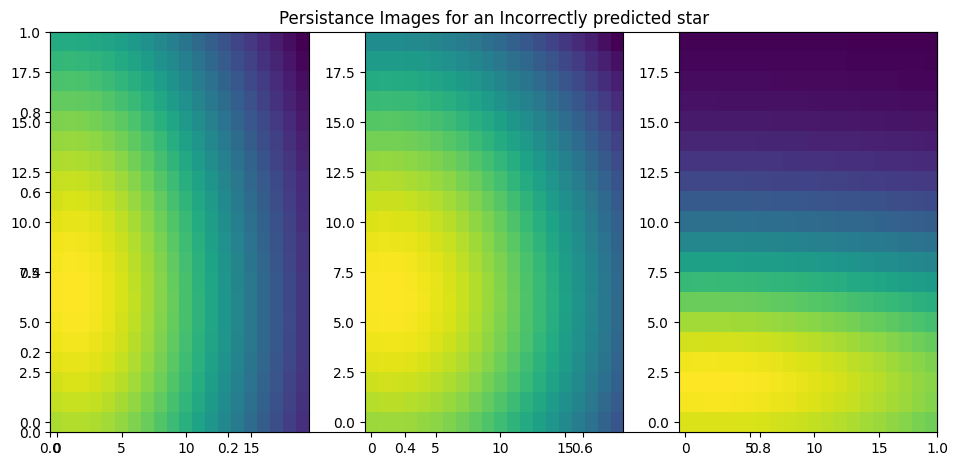

In [426]:
# galaxy
i = galaxies_incorrect[0][10]
plt.figure(figsize=(10, 5))
plt.title('Persistance Images for an Incorrectly predicted star')
plt.subplot(1,3,1)
plt.imshow(test_features[i][0], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,2)
plt.imshow(test_features[i][1], origin="lower", cmap="viridis", aspect="auto")

plt.subplot(1,3,3)
plt.imshow(test_features[i][2], origin="lower", cmap="viridis", aspect="auto")

plt.tight_layout()

print(f'Predicted: Galaxy. Actual: Star')
print(torch.argmax(y_pred_test[i]),test_targets[i])
plt.show()

It's interesting how these persistence image examples for incorrectly predicted objects look as they should. The star looks like a star's persistence image, likewise with the galaxy and quasar.

# Model 2: LogisticRegression from ScikitLearn

We want to use the following two models as a comparison to our TDA model. For the LR model, we're using Scikit Learn's default Logistic Regression model with the lbfgs solver. We just wanted to see how the default model performed, so we're using all of the default hyperparameter settings.

Accuracy: 0.9418


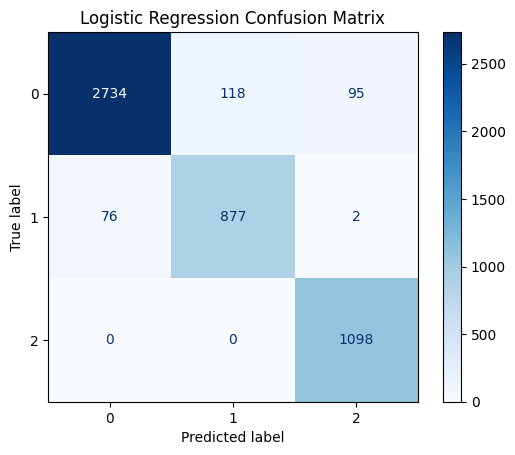

In [436]:
from sklearn.linear_model import LogisticRegression

data_lr = pd.read_csv("star_classification.csv")

data_lr["redshift"] = 1/(1+data_lr["redshift"])

X_lr = data_lr[["u","g","r","i","z","redshift"]].to_numpy()
y_lr = data_lr["class"].to_numpy()

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.05)

model_lr = LogisticRegression(solver="lbfgs", max_iter=5000,class_weight='balanced')
model_lr.fit(X_train_lr, y_train_lr)
print("Accuracy:", model_lr.score(X_test_lr, y_test_lr))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_lr = model_lr.predict(X_test_lr)

# making a confusion matrix
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)

disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot(cmap="Blues", values_format="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [437]:
# galaxy accuracy
galaxy_mask_lr = np.where(y_test_lr=='GALAXY')
galaxies_correct_lr = np.mean((y_test_lr[galaxy_mask_lr]==y_pred_lr[galaxy_mask_lr]))

# quasar accuracy
quasar_mask_lr = np.where(y_test_lr=='QSO')
quasar_correct_lr = np.mean((y_test_lr[quasar_mask_lr]==y_pred_lr[quasar_mask_lr]))

# star accuracy
star_mask_lr = np.where(y_test_lr=='STAR')
star_correct_lr = np.mean((y_test_lr[star_mask_lr]==y_pred_lr[star_mask_lr]))

print(f'Galaxy accuracy: {(galaxies_correct_lr*100):.2f}%')
print(f'Quasar accuracy: {(quasar_correct_lr*100):.2f}%')
print(f'Star accuracy: {(star_correct_lr*100):.2f}%')

Galaxy accuracy: 92.77%
Quasar accuracy: 91.83%
Star accuracy: 100.00%


The LR model performs better than the TDA model, achieving an accuracy of 94% in this run. Additionally, the accuracy for quasars increased significantly, and the accuracy for star detection reached 100%.

# Model 3: FCN Portion of our CNN Model

For the next model, we look at just the fully connected network portion of our CNN model. That is, the model is just the sequential fully connected block from previously:

## Prepare Data

In [483]:
# importing the data
data_fcn = pd.read_csv("star_classification.csv")

# scanning for weird values and dropping that
data_fcn = data.replace(-9999,np.NaN) 
data_fcn = data.dropna()

# adding a label dictionary to attach each class of object to a number
label_dict_fcn = {"GALAXY":0,"QSO":1,"STAR":2}

# scaling and selecting the features we want to use in the model training
scaler = StandardScaler()
feature_list_fcn = ["u","g","r","i","z","redshift","alpha","delta","MJD"]
data_fcn[feature_list_fcn] = scaler.fit_transform(data_fcn[feature_list_fcn])
threshold = 4
data_fcn = data_fcn[~ (data_fcn[feature_list_fcn]**2 > threshold**2).any(axis=1)]
data["redshift"] = 1/(1+data["redshift"])


# setting X and y for model training
X_fcn = data_fcn[feature_list_fcn].to_numpy()
y_fcn = data_fcn["class"].replace(label_dict_fcn).to_numpy()

/var/folders/hw/6n5293rd1yxb4t280d29n1t00000gn/T/ipykernel_56358/3675791248.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_fcn = data_fcn["class"].replace(label_dict_fcn).to_numpy()


In [484]:
# splitting into training, testing, and validation sets
train_features_fcn, test_features_fcn, train_targets_fcn, test_targets_fcn = train_test_split(
                                                X_fcn, 
                                                y_fcn, 
                                                test_size=0.1, 
                                                random_state=2)


validation_features_fcn, test_features_fcn, validation_targets_fcn, test_targets_fcn = train_test_split(
                                                    test_features_fcn, 
                                                    test_targets_fcn, 
                                                    test_size=0.5, 
                                                    random_state=2)

## Define Model

In [485]:
import torch.nn as nn

class simpleFCN(nn.Module):
    def __init__(self, input_dim, num_of_classes, hidden_layer_size):

        super(simpleFCN, self).__init__()
        # The fully connected block 
        # three layers with linear activation and dropout for regularization
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_layer_size),
            nn.Dropout(0.3),
            nn.Linear(hidden_layer_size, num_of_classes)
        )

    def forward(self, x):
        #x = nn.functional.relu((self.fc_layers(x)))
        x = self.fc_layers(x)
        return x

## Define Hyperparameters

In [486]:
model = simpleFCN(
    input_dim = 9, 
    num_of_classes = 3, 
    hidden_layer_size = 20,
    
)

learning_rate = 0.01
epochs  = 15

# old portion when we added weights to the model, it makes the accuracy go down when we add them.
class_counts=np.bincount(train_targets)
total_samples=len(train_targets)
weights = total_samples / (len(class_counts) * class_counts)
class_weights_tensor = torch.FloatTensor(weights)

# loss_func = torch.nn.CrossEntropyLoss(weight=class_weights_tensor) # old loss function with weights

loss_func_fcn = torch.nn.CrossEntropyLoss()
optimizer_fcn = torch.optim.Adam(model.parameters(), lr = learning_rate)

## Identify Tracked Values

In [487]:
train_loss_list_fcn = []
validation_accuracy_list_fcn = np.zeros((epochs,))

In [488]:
train_inputs_fcn = torch.from_numpy(train_features_fcn).float()
train_targets_fcn = torch.from_numpy(train_targets_fcn.astype(int))

validation_inputs_fcn = torch.from_numpy(validation_features_fcn).float()
validation_targets_fcn = torch.from_numpy(validation_targets_fcn.astype(int))

testing_inputs_fcn = torch.from_numpy(test_features_fcn).float()
testing_targets_fcn = torch.from_numpy(test_targets_fcn.astype(int)) 

In [489]:
batchsize = 1000

# Use torch.split() function to split the training inputs/targets into mini-batches
train_batches_features_fcn = torch.split(train_inputs_fcn, batchsize)
train_batches_targets_fcn = torch.split(train_targets_fcn, batchsize)

# length of train_batches_features = total number of mini-batches in the training set
batch_split_num_fcn = len(train_batches_features_fcn)

## Train Model

In [490]:
import tqdm # Use "for epoch in tqdm.trange(epochs):" to see the progress bar


for epoch in range(epochs):
    model.train() # Set the model to training mode
    
    for k in range(batch_split_num_fcn):
    
        optimizer_fcn.zero_grad()
            
        train_batch_outputs = model(train_batches_features_fcn[k])

        loss = loss_func(train_batch_outputs, train_batches_targets_fcn[k])

        train_loss_list_fcn.append(loss.item())

        loss.backward()

        optimizer_fcn.step()

    # Compute Validation Accuracy ----------------------------------------------------------------------

    with torch.no_grad():
        model.eval() # Set the model to evaluation mode to turn off dropout layers

        validation_outputs = model(validation_inputs_fcn)

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets_fcn).type(torch.FloatTensor)
        
        validation_accuracy = np.round(correct.mean().numpy() * 100, 2)
        
        print("Epoch: "+ str(epoch), 
              "Validation Accuracy: " + str(validation_accuracy) + '%', flush=True)
        
        
        

        validation_accuracy_list_fcn[epoch] = correct.mean()


Epoch: 0 Validation Accuracy: 95.57%
Epoch: 1 Validation Accuracy: 95.51%
Epoch: 2 Validation Accuracy: 95.96%
Epoch: 3 Validation Accuracy: 96.0%
Epoch: 4 Validation Accuracy: 96.18%
Epoch: 5 Validation Accuracy: 96.22%
Epoch: 6 Validation Accuracy: 96.18%
Epoch: 7 Validation Accuracy: 96.24%
Epoch: 8 Validation Accuracy: 96.26%
Epoch: 9 Validation Accuracy: 96.28%
Epoch: 10 Validation Accuracy: 96.38%
Epoch: 11 Validation Accuracy: 96.38%
Epoch: 12 Validation Accuracy: 96.38%
Epoch: 13 Validation Accuracy: 96.38%
Epoch: 14 Validation Accuracy: 96.4%


## Visualize and Evaluate Model

Text(0, 0.5, 'validation accuracy')

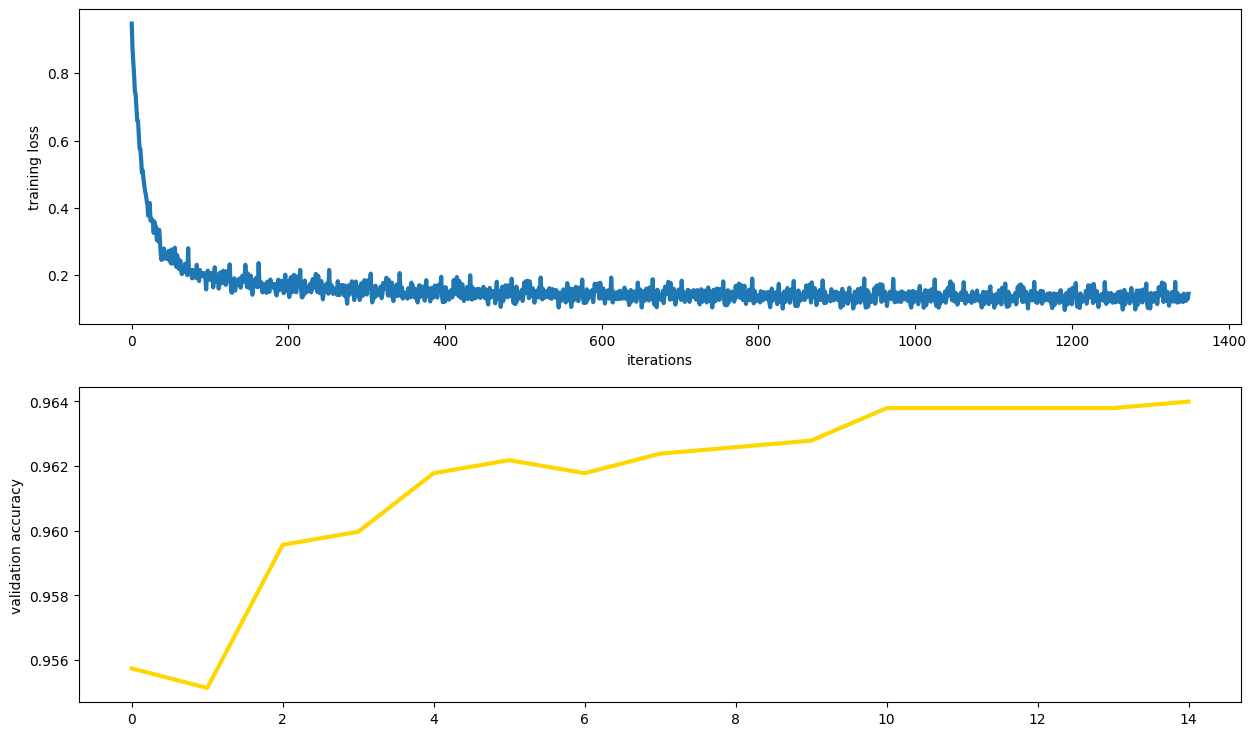

In [491]:
plt.figure(figsize = (15, 9))

plt.subplot(2, 1, 1)
plt.plot(train_loss_list_fcn, linewidth = 3)
plt.ylabel("training loss")
plt.xlabel("iterations")


plt.subplot(2, 1, 2)
plt.plot(validation_accuracy_list_fcn, linewidth = 3, color = 'gold')
plt.ylabel("validation accuracy")

Testing Accuracy: 0.9660028


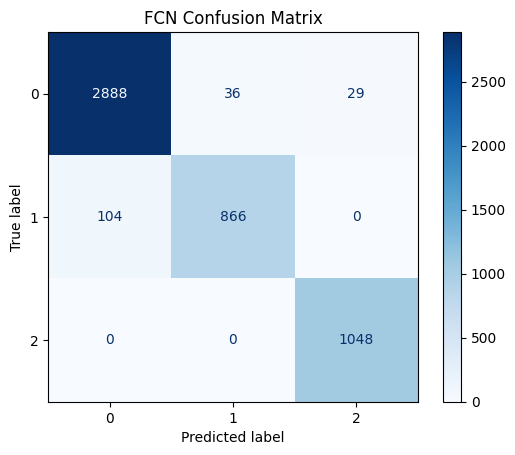

In [492]:
# Compute the testing accuracy 

with torch.no_grad():
    model.eval() # Set the model to evaluation mode to turn off dropout layers
    
    y_pred_test = model(testing_inputs_fcn)
     
    correct = (torch.argmax(y_pred_test, dim=1) == testing_targets_fcn).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()))


from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(testing_targets_fcn, torch.argmax(y_pred_test, dim=1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("FCN Confusion Matrix")
plt.show()

In [506]:
# galaxy accuracy
galaxy_mask_fcn = np.where(testing_targets_fcn==0)
galaxies_correct = np.mean((testing_targets_fcn[galaxy_mask_fcn]==torch.argmax(y_pred_test[galaxy_mask_fcn], dim=1)).numpy())

# quasar accuracy
quasar_mask_fcn = np.where(testing_targets_fcn==1)
quasar_correct = np.mean((testing_targets_fcn[quasar_mask_fcn]==torch.argmax(y_pred_test[quasar_mask_fcn], dim=1)).numpy())

# star accuracy
star_mask_fcn = np.where(testing_targets_fcn==2)
star_correct = np.mean((testing_targets_fcn[star_mask_fcn]==torch.argmax(y_pred_test[star_mask_fcn], dim=1)).numpy())

print(f'Galaxy accuracy: {(galaxies_correct*100):.2f}%')
print(f'Quasar accuracy: {(quasar_correct*100):.2f}%')
print(f'Star accuracy: {(star_correct*100):.2f}%')

Galaxy accuracy: 97.80%
Quasar accuracy: 89.28%
Star accuracy: 100.00%


Just the FCN portion of our CNN model performs much better! This model takes the scaled input data and feeds it directly into the linear layers. Galaxy accuraccy increased by a lot from the previous LR model, and the quasar accuracy also increased significantly from the TDA model.

# Final Thoughts

From testing these three models, we conclude that our TDA approach isn't the best for this situation. Even very simple approaces can yield great results!